In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn jupyter imbalanced-learn scipy

### **Cargar de Datos Sintéticos**

In [2]:
import pandas as pd
import json

with open('data/Child.json', 'r') as f:
    child_data_json = json.load(f)
df_child = pd.DataFrame(child_data_json)

with open('data/Anthropometry.json', 'r') as f:
    anthropometry_data_json = json.load(f)
df_anthropometry = pd.DataFrame(anthropometry_data_json)

with open('data/BehavioralData.json', 'r') as f:
    behavioral_data_json = json.load(f)
df_behavioral_data = pd.DataFrame(behavioral_data_json)

with open('data/Household.json', 'r') as f:
    household_data_json = json.load(f)
df_household = pd.DataFrame(household_data_json)

with open('data/MedicalHistory.json', 'r') as f:
    medical_history_data_json = json.load(f)
df_medical_history = pd.DataFrame(medical_history_data_json)

with open('data/ClassificationResult.json', 'r') as f:
    classification_result_json = json.load(f)
df_classification_result = pd.DataFrame(classification_result_json)

### **Fase 1: Exploración Inicial de Datos (EDA)**

#### **Verificar Carga**

In [ ]:
print("Información de df_child:")
df_child.info()
print(df_child.head())

print("\nInformación de df_anthropometry:")
df_anthropometry.info()
print(df_anthropometry.head())

print("\nInformación de df_behavioral_data:")
df_behavioral_data.info()
print(df_behavioral_data.head())

print("\nInformación de df_household:")
df_household.info()
print(df_household.head())

print("\nInformación de df_medical_history:")
df_medical_history.info()
print(df_medical_history.head())

print("\nInformación de df_classification_result:")
df_classification_result.info()
print(df_classification_result.head())

#### **Descripción de Datos**

In [8]:
print(df_anthropometry.describe())
print(df_behavioral_data.describe())
print(df_household.describe())
print(df_medical_history.describe())
print(df_classification_result.describe())
print(df_child.describe())

        measure_id     child_id       weight       height         muac  \
count  1215.000000  1215.000000  1215.000000  1215.000000  1215.000000   
mean    608.000000   149.617284    11.545004    71.710288    12.280576   
std     350.884596    87.253966     6.035092    14.703149     2.229490   
min       1.000000     1.000000     0.670000    45.500000     7.900000   
25%     304.500000    72.000000     6.305000    59.300000    10.400000   
50%     608.000000   153.000000    11.080000    70.000000    12.100000   
75%     911.500000   224.000000    16.195000    83.000000    13.900000   
max    1215.000000   300.000000    27.140000   110.700000    18.100000   

               bmi  z_score_weight  z_score_height  
count  1215.000000     1215.000000     1215.000000  
mean     20.521728       -0.035934        0.036749  
std       4.830234        1.013376        0.967347  
min       2.400000       -3.180000       -2.820000  
25%      17.900000       -0.735000       -0.610000  
50%      21.600

#### **Valores Únicos**

In [11]:
print(df_child['gender'].unique())
print(df_household['urban'].unique())
print(df_behavioral_data['appetite_scale'].unique())
print(df_classification_result['classification'].unique())
print(df_anthropometry['z_score_height'].unique())
print(df_medical_history['breastfeeding_duration'].unique())

['F' 'M']
['Rural' 'Urbano']
[ 8  5  4 10  3  7  1  9  6  2]
['sobrepeso' 'normal' 'desnutriciÃ³n' 'desnutriciÃ³n_aguda' 'obesidad']
[-1.39 -0.9   0.41  1.89 -1.21 -1.2   0.06  0.02  0.97  1.79  1.46 -0.43
 -2.18 -0.21 -1.27  0.48  0.44  1.24  1.49 -1.12  0.3  -1.57  0.49  0.7
 -1.48  0.01  0.14 -1.02 -0.8   0.61  0.13  0.25 -1.31 -0.92 -0.18 -0.49
  2.1  -0.25  1.02 -0.02 -1.29  0.34 -2.55  0.58 -1.71 -0.35  0.83 -0.73
  0.65  1.37 -0.32 -0.08  0.63 -0.17  0.08  1.23  0.79  0.88 -0.64 -0.2
  0.73  1.69  1.22  0.35  0.21  0.98  0.86 -0.15 -0.67 -0.11  0.56 -1.05
 -0.96 -1.32 -0.72  0.33  0.76  0.29 -0.44 -0.42  1.17  0.82 -0.1  -0.68
 -0.16  1.21 -0.74  0.46  1.2  -0.37  1.92  1.4   0.4  -2.19  1.43  0.04
  0.37 -0.38 -0.46  3.23 -0.59 -0.23  0.8  -1.3   1.06  0.5  -0.26 -0.55
  0.75 -1.63  1.6  -0.45 -0.24 -1.93  0.03 -2.06  0.67  0.78 -0.29  0.87
 -2.1  -1.8  -1.89  0.92  0.55 -1.03  0.66 -0.51  0.12 -0.09  0.22 -0.48
 -1.77  1.01 -1.95  0.27 -0.99  0.31  0.62 -1.28  0.81  0.2   1.51

#### **Distribuciones**

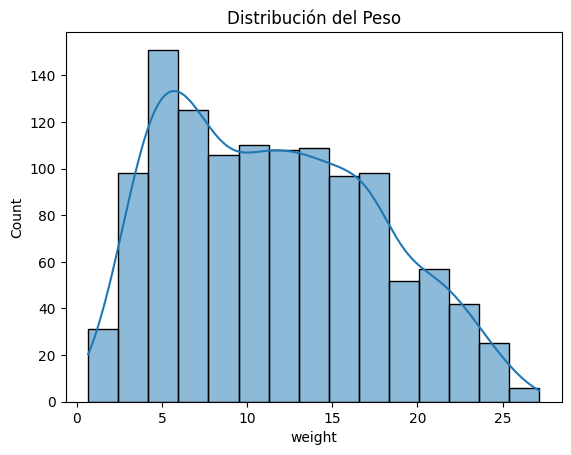

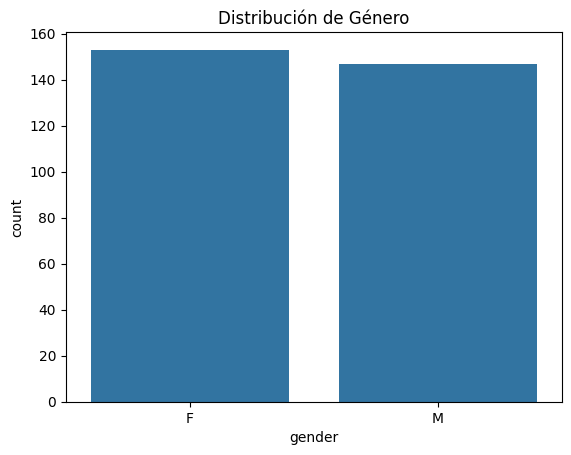

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_anthropometry['weight'], kde=True)
plt.title('Distribución del Peso')
plt.show()

sns.countplot(x='gender', data=df_child)
plt.title('Distribución de Género')
plt.show()

#### **Unir Dataframes**

In [41]:
import pandas as pd

df_target = pd.DataFrame(classification_result_json)

# --- 1) Conversión a datetime y tipos numéricos ---
print("\nConvirtiendo tipos de datos iniciales...")
df_child['birthdate'] = pd.to_datetime(df_child['birthdate'])
df_anthropometry['measure_date'] = pd.to_datetime(df_anthropometry['measure_date'])
df_behavioral_data['observation_date'] = pd.to_datetime(df_behavioral_data['observation_date'])
df_target['prediction_date'] = pd.to_datetime(df_target['prediction_date'])

# Asegurar que child_id es numérico en todas partes
df_child['child_id'] = pd.to_numeric(df_child['child_id'])
df_anthropometry['child_id'] = pd.to_numeric(df_anthropometry['child_id'])
df_behavioral_data['child_id'] = pd.to_numeric(df_behavioral_data['child_id'])
df_target['child_id'] = pd.to_numeric(df_target['child_id'])
if 'household_id' in df_child.columns: # si se usa para merge
    df_child['household_id'] = pd.to_numeric(df_child['household_id'])
if 'household_id' in df_household.columns:
     df_household['household_id'] = pd.to_numeric(df_household['household_id'])
if 'history_id' in df_medical_history.columns: # si se usa para merge
    df_medical_history['history_id'] = pd.to_numeric(df_medical_history['history_id'])
df_medical_history['child_id'] = pd.to_numeric(df_medical_history['child_id'])


# Convertir columnas numéricas que se promediarán (con manejo de errores por si no son numéricas)
cols_to_convert_anthro = ['weight', 'height', 'muac', 'bmi', 'z_score_weight', 'z_score_height']
for col in cols_to_convert_anthro:
    if col in df_anthropometry.columns:
        df_anthropometry[col] = pd.to_numeric(df_anthropometry[col], errors='coerce')

cols_to_convert_behav = ['meals_per_day', 'physical_activity_hours', 'sleep_hours', 'appetite_scale']
for col in cols_to_convert_behav:
    if col in df_behavioral_data.columns:
        df_behavioral_data[col] = pd.to_numeric(df_behavioral_data[col], errors='coerce')

print("Conversión de tipos de datos completada.")

# --- 2) Joins estáticos (Child, Household, Medical History con Target) ---
print("\nRealizando joins estáticos...")
df_child_household = pd.merge(df_child, df_household, on='household_id', how='left')
df_ml_intermediate = pd.merge(df_target, df_child_household, on='child_id', how='left')
df_ml_intermediate = pd.merge(df_ml_intermediate, df_medical_history, on='child_id', how='left', suffixes=('', '_med'))
print("Joins estáticos completados.")

# --- 3) Preparar DataFrame izquierdo (df_ml_to_merge) ---
# Ordenar MUY ESTRICTAMENTE y luego eliminar duplicados de (child_id, prediction_date),
# quedándose con el último registro según el orden (result_id si existe).
sort_cols_ml = ['child_id', 'prediction_date']
if 'result_id' in df_ml_intermediate.columns: # result_id viene de df_target
    df_ml_intermediate['result_id'] = pd.to_numeric(df_ml_intermediate['result_id'])
    sort_cols_ml.append('result_id')

df_ml_to_merge = (
    df_ml_intermediate
    .sort_values(sort_cols_ml, ascending=True)
    .drop_duplicates(subset=['child_id', 'prediction_date'], keep='last')
    .reset_index(drop=True)
)
# **Asegurar el orden FINAL para merge_asof**
df_ml_to_merge = df_ml_to_merge.sort_values(['child_id', 'prediction_date']).reset_index(drop=True)
print(f"Filas en df_ml_to_merge (izquierdo principal): {len(df_ml_to_merge)}")

# --- 4) Preparar DataFrame derecho para antropometría (df_anthro_to_merge) ---
# Agrupar por child_id y measure_date, y tomar el promedio de las métricas.
print("\nProcesando datos antropométricos (agregación)...")
cols_to_average_anthro = ['weight', 'height', 'muac', 'bmi', 'z_score_weight', 'z_score_height']
agg_dict_anthro = {col: 'mean' for col in cols_to_average_anthro if col in df_anthropometry.columns}
if not agg_dict_anthro:
    print("ADVERTENCIA: No se encontraron columnas para promediar en datos antropométricos.")

df_anthro_to_merge = (
    df_anthropometry
    .sort_values(['child_id', 'measure_date']) # Ordenar antes de agrupar por si se usa 'first' o 'last'
    .groupby(['child_id', 'measure_date'], as_index=False)
    .agg(agg_dict_anthro)
    .sort_values(['child_id', 'measure_date']) # Asegurar orden después de groupby
    .reset_index(drop=True)
)
print(f"Filas en df_anthro_to_merge (derecho antropometría): {len(df_anthro_to_merge)}")


# --- 5) MERGE ANTROPOMÉTRICO (child_id por child_id) ---
print("\nIniciando merge antropométrico (child_id por child_id)...")
merged_anthro_parts = []
all_child_ids_anthro = df_ml_to_merge['child_id'].unique()

for cid in all_child_ids_anthro:
    temp_left_anthro = df_ml_to_merge[df_ml_to_merge['child_id'] == cid].copy()
    temp_right_anthro = df_anthro_to_merge[df_anthro_to_merge['child_id'] == cid].copy()

    if temp_right_anthro.empty:
        anthro_cols_to_add = []
        # Añadir measure_date con sufijo si no está ya en temp_left_anthro
        # (esto es poco probable si la lógica de sufijos es consistente)
        if 'measure_date_anthro' not in temp_left_anthro.columns and 'measure_date' not in temp_left_anthro.columns :
             anthro_cols_to_add.append('measure_date_anthro')
        for col in df_anthro_to_merge.columns: # Usar columnas del DF procesado df_anthro_to_merge
            if col not in ['child_id', 'measure_date']: # No añadir la clave 'by' ni la clave 'on' sin sufijo
                anthro_cols_to_add.append(col + '_anthro')
        
        temp_merged_manual_anthro = temp_left_anthro.copy()
        for col_name in anthro_cols_to_add:
            if 'date' in col_name.lower(): temp_merged_manual_anthro[col_name] = pd.NaT
            else: temp_merged_manual_anthro[col_name] = pd.NA
        merged_anthro_parts.append(temp_merged_manual_anthro)
        continue
    try:
        temp_merged_manual_anthro = pd.merge_asof(
            temp_left_anthro, temp_right_anthro,
            left_on='prediction_date', right_on='measure_date',
            by='child_id', direction='backward', suffixes=('_target', '_anthro')
        )
        merged_anthro_parts.append(temp_merged_manual_anthro)
    except Exception as e_manual_anthro:
        print(f"ERROR en merge antropométrico manual para child_id: {cid} - {e_manual_anthro}")
        # Decidir cómo manejar errores: ¿detener, o añadir temp_left_anthro sin datos de la derecha?
        # Por ahora, añadimos temp_left_anthro para no perder filas, pero marcamos el error.
        merged_anthro_parts.append(temp_left_anthro) # Opcional: o no añadir nada


if merged_anthro_parts:
    df_ml_merged_anthro = pd.concat(merged_anthro_parts, ignore_index=True)
    print(f"✅ Merge antropometría completado: {len(df_ml_merged_anthro)} filas.")
else:
    print("❌ No se generaron datos en el merge antropométrico. df_ml_to_merge podría estar vacío.")
    df_ml_merged_anthro = df_ml_to_merge.copy() # Para que el script no falle más adelante

# --- 6) Preparar DataFrame derecho para datos conductuales (df_behav_to_merge) ---
print("\nProcesando datos conductuales (agregación)...")
cols_to_average_behav = ['meals_per_day', 'physical_activity_hours', 'sleep_hours', 'appetite_scale']
agg_dict_behav = {col: 'mean' for col in cols_to_average_behav if col in df_behavioral_data.columns}
if 'behavior_notes' in df_behavioral_data.columns: # Tomar la última nota si hay varias
    agg_dict_behav['behavior_notes'] = 'last'
if not agg_dict_behav:
    print("ADVERTENCIA: No se encontraron columnas para agregar/promediar en datos conductuales.")


df_behav_to_merge = (
    df_behavioral_data
    .sort_values(['child_id', 'observation_date']) # Añadir 'behavior_id' si existe para desempate estable antes de 'last'
    .groupby(['child_id', 'observation_date'], as_index=False)
    .agg(agg_dict_behav)
    .sort_values(['child_id', 'observation_date']) # Asegurar orden después de groupby
    .reset_index(drop=True)
)
print(f"Filas en df_behav_to_merge (derecho conductual): {len(df_behav_to_merge)}")

# --- 7) Prepara df_ml_merged_anthro para el segundo merge_asof ---
# Reordenar por si acaso, aunque concat debería preservar el orden de los bloques si los bloques estaban ordenados.
df_ml_post_anthro_to_merge = df_ml_merged_anthro.sort_values(['child_id', 'prediction_date']).reset_index(drop=True)


# --- 8) MERGE CONDUCTUAL (child_id por child_id) ---
print("\nIniciando merge conductual (child_id por child_id)...")
merged_behav_parts = []
all_child_ids_behav = df_ml_post_anthro_to_merge['child_id'].unique()

for cid_behav in all_child_ids_behav:
    temp_left_behav = df_ml_post_anthro_to_merge[df_ml_post_anthro_to_merge['child_id'] == cid_behav].copy()
    temp_right_behav = df_behav_to_merge[df_behav_to_merge['child_id'] == cid_behav].copy()

    if temp_right_behav.empty:
        behav_cols_to_add = []
        # Añadir observation_date con sufijo
        if 'observation_date_behav' not in temp_left_behav.columns and 'observation_date' not in temp_left_behav.columns:
             behav_cols_to_add.append('observation_date_behav')
        for col in df_behav_to_merge.columns:
            if col not in ['child_id', 'observation_date']:
                behav_cols_to_add.append(col + '_behav') # Asumimos que '_main' ya está en el left
        
        temp_merged_manual_behav = temp_left_behav.copy()
        for col_name in behav_cols_to_add:
            if 'date' in col_name.lower(): temp_merged_manual_behav[col_name] = pd.NaT
            else: temp_merged_manual_behav[col_name] = pd.NA
        merged_behav_parts.append(temp_merged_manual_behav)
        continue
    try:
        temp_merged_manual_behav = pd.merge_asof(
            temp_left_behav, temp_right_behav,
            left_on='prediction_date', # O la fecha de antropometría si esa es tu referencia temporal clave
            right_on='observation_date',
            by='child_id', direction='backward', suffixes=('_main', '_behav') # Cuidado con los sufijos acumulados
        )
        merged_behav_parts.append(temp_merged_manual_behav)
    except Exception as e_manual_behav:
        print(f"ERROR en merge conductual manual para child_id: {cid_behav} - {e_manual_behav}")
        merged_behav_parts.append(temp_left_behav)


if merged_behav_parts:
    df_ml_final = pd.concat(merged_behav_parts, ignore_index=True)
    print(f"✅ Merge conductual completado: {len(df_ml_final)} filas.")
else:
    print("❌ No se generaron datos en el merge conductual. df_ml_post_anthro_to_merge podría estar vacío.")
    df_ml_final = df_ml_post_anthro_to_merge.copy()

# --- 9) Conteo de nulos y cálculo de edad ---
print("\nNulos por columna tras merges:")
print(df_ml_final.isnull().sum().sort_values(ascending=False))

print("\nCalculando edad...")
# Determinar la fecha de referencia para la edad (idealmente de la medición antropométrica)
date_col_anthro_actual = None
if 'measure_date_anthro' in df_ml_final.columns:
    date_col_anthro_actual = 'measure_date_anthro'
elif 'measure_date' in df_ml_final.columns and not df_ml_final['measure_date'].equals(df_ml_final['prediction_date']): # Asegurar que no es prediction_date
    # Esta condición es un poco heurística; idealmente, los sufijos hacen esto claro.
    # Si 'measure_date' existe y es diferente de 'prediction_date', asumimos que es de antropometría.
    date_col_anthro_actual = 'measure_date'

if date_col_anthro_actual and not df_ml_final[date_col_anthro_actual].isnull().all() and 'birthdate' in df_ml_final.columns:
    print(f"Usando '{date_col_anthro_actual}' para calcular la edad.")
    df_ml_final['age_months'] = ((df_ml_final[date_col_anthro_actual] - df_ml_final['birthdate']).dt.days / 30.4375).round()
elif 'prediction_date' in df_ml_final.columns and 'birthdate' in df_ml_final.columns:
    print("Usando 'prediction_date' como fallback para calcular la edad.")
    df_ml_final['age_months'] = ((df_ml_final['prediction_date'] - df_ml_final['birthdate']).dt.days / 30.4375).round()
else:
    print("ADVERTENCIA: No se pudo calcular 'age_months'. Faltan columnas de fecha necesarias ('birthdate' y una fecha de referencia).")
    df_ml_final['age_months'] = pd.NA


print("\nPrimeras filas de df_ml_final:")
print(df_ml_final.head())

df_ml_final.to_csv('data/df_ml_final.csv', index=False)


Convirtiendo tipos de datos iniciales...
Conversión de tipos de datos completada.

Realizando joins estáticos...
Joins estáticos completados.
Filas en df_ml_to_merge (izquierdo principal): 870

Procesando datos antropométricos (agregación)...
Filas en df_anthro_to_merge (derecho antropometría): 870

Iniciando merge antropométrico (child_id por child_id)...
✅ Merge antropometría completado: 870 filas.

Procesando datos conductuales (agregación)...
Filas en df_behav_to_merge (derecho conductual): 300

Iniciando merge conductual (child_id por child_id)...
✅ Merge conductual completado: 870 filas.

Nulos por columna tras merges:
behavior_notes                635
appetite_scale                635
sleep_hours                   635
physical_activity_hours       635
meals_per_day                 635
observation_date              635
child_id                        0
result_id                       0
prediction_date                 0
classification                  0
urban                     

#### **Seleccionar Variables X y Y**

In [ ]:
import pandas as pd

# Cargar df_ml_final.csv para inspeccionar sus columnas
try:
    df_ml_final_inspect = pd.read_csv('data/csv/df_ml_final.csv')
    print("df_ml_final.csv cargado exitosamente para inspección.")
    print("Columnas disponibles en df_ml_final.csv:")
    for col in df_ml_final_inspect.columns:
        print(f"- {col}")
except FileNotFoundError:
    print("ERROR: No se pudo encontrar 'df_ml_final.csv'. Asegúrate de que el archivo esté en la ubicación correcta.")
    # Detener la ejecución si el archivo no se puede cargar, ya que es esencial.
    raise SystemExit("Archivo df_ml_final.csv no encontrado.")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
import ast # Para convertir strings de listas/diccionarios a objetos Python

try:
    df_ml_final = pd.read_csv('data/csv/df_ml_final.csv') # Asumiendo que este es el archivo correcto
    print("df_ml_final cargado.")
except FileNotFoundError:
    print("ERROR: 'df_ml_final.csv' no encontrado. Asegúrate de que la ruta sea correcta.")
    raise SystemExit("df_ml_final.csv no encontrado.")

date_columns_to_convert = [
    'prediction_date', 'birthdate',
    'measure_date', 'observation_date' 
]
print("\nConvirtiendo columnas de fecha a datetime...")
for col in date_columns_to_convert:
    if col in df_ml_final.columns:
        try:
            df_ml_final[col] = pd.to_datetime(df_ml_final[col])
            print(f"Columna '{col}' convertida a datetime.")
        except Exception as e:
            print(f"Error al convertir la columna '{col}' a datetime: {e}")
    else:
         print(f"Advertencia: Columna de fecha '{col}' no encontrada en df_ml_final.")


# Asegurar que age_months existe o calcularlo
if 'age_months' not in df_ml_final.columns and 'birthdate' in df_ml_final.columns:
    print("Calculando 'age_months'...")
    date_col_anthro_actual = None
    if 'measure_date' in df_ml_final.columns and not df_ml_final['measure_date'].isnull().all():
        date_col_anthro_actual = 'measure_date'
    elif 'measure_date' in df_ml_final.columns and not df_ml_final['measure_date'].isnull().all() and \
         ('prediction_date' not in df_ml_final.columns or not df_ml_final['measure_date'].equals(df_ml_final['prediction_date'])):
        date_col_anthro_actual = 'measure_date'

    if date_col_anthro_actual:
        print(f"Usando '{date_col_anthro_actual}' para calcular la edad.")
        df_ml_final['age_months'] = ((df_ml_final[date_col_anthro_actual] - df_ml_final['birthdate']).dt.days / 30.4375).round()
    elif 'prediction_date' in df_ml_final.columns:
        print("Usando 'prediction_date' como fallback para calcular la edad.")
        df_ml_final['age_months'] = ((df_ml_final['prediction_date'] - df_ml_final['birthdate']).dt.days / 30.4375).round()
    else:
        print("ADVERTENCIA: No se pudo calcular 'age_months'. Faltan columnas de fecha.")
        df_ml_final['age_months'] = pd.NA
elif 'age_months' in df_ml_final.columns:
    print("'age_months' ya presente en df_ml_final.")


# --- 1) Definición de la Variable Objetivo (y) ---
print("\n--- 1) Definiendo Variable Objetivo (y) ---")
if 'classification' in df_ml_final.columns:
    y = df_ml_final['classification'].copy()
    print("Variable objetivo 'y' (classification) seleccionada.")
    print("Distribución de clases en 'y':")
    print(y.value_counts(normalize=True) * 100)
else:
    raise KeyError("La columna 'classification' no se encuentra en df_ml_final. No se puede definir 'y'.")

# --- 2) Preprocesamiento de Características Complejas ---
print("\n--- 2) Preprocesando Características Complejas ---")
df_features_processed = df_ml_final.copy()

def parse_string_representation(x, target_type):
    if pd.isna(x): return target_type()
    if isinstance(x, target_type): return x
    if isinstance(x, str):
        try:
            evaluated = ast.literal_eval(x)
            return evaluated if isinstance(evaluated, target_type) else target_type()
        except (ValueError, SyntaxError, TypeError): return target_type()
    return target_type()

newly_generated_feature_columns = []

# Procesar 'preexisting_conditions'
col_preexisting_conditions = 'preexisting_conditions'
if col_preexisting_conditions in df_features_processed.columns:
    print(f"Procesando '{col_preexisting_conditions}'...")
    df_features_processed['temp_list_cond'] = df_features_processed[col_preexisting_conditions].apply(
        lambda x: parse_string_representation(x, target_type=list)
    )
    list_for_mlb_cond = df_features_processed['temp_list_cond'].fillna("").apply(lambda x: x if isinstance(x, list) else [])
    
    if not list_for_mlb_cond.empty and list_for_mlb_cond.apply(len).sum() > 0: # Evitar MLB si todas las listas están vacías
        mlb_cond = MultiLabelBinarizer()
        try:
            conditions_matrix = mlb_cond.fit_transform(list_for_mlb_cond)
            
            # Asegurar que mlb_cond.classes_ es una lista de strings para Pylance
            initial_column_names_cond = [str(c) for c in mlb_cond.classes_]

            if conditions_matrix.shape[1] == len(initial_column_names_cond):
                temp_conditions_df = pd.DataFrame(
                    conditions_matrix, #type: ignore
                    columns=initial_column_names_cond, # Usar la lista de strings explícita
                    index=df_features_processed.index
                ) #type: ignore
                
                cols_to_keep_and_rename = {}
                for original_class_name in initial_column_names_cond: # Iterar sobre los nombres originales
                    if original_class_name.lower() != 'ninguna':
                        new_col_name = f"cond_{original_class_name.replace(' ', '_').replace('-', '_').lower()}"
                        cols_to_keep_and_rename[original_class_name] = new_col_name # Mapear original a nuevo
                
                if cols_to_keep_and_rename:
                    # Seleccionar por los nombres originales (keys del dict) y luego renombrar
                    conditions_encoded = temp_conditions_df[list(cols_to_keep_and_rename.keys())].rename(
                        columns=cols_to_keep_and_rename
                    )
                    df_features_processed = pd.concat([df_features_processed, conditions_encoded], axis=1)
                    print(f"  Nuevas cols de condiciones: {list(conditions_encoded.columns)}")
                    newly_generated_feature_columns.extend(conditions_encoded.columns)
                else:
                    print("  No hay condiciones que mantener después de filtrar 'ninguna'.")
            else:
                print(f"  ADVERTENCIA: Discrepancia en dimensiones para '{col_preexisting_conditions}'. Matriz: {conditions_matrix.shape[1]} cols, Clases MLB: {len(initial_column_names_cond)}")
        except Exception as e:
            print(f"  ERROR en '{col_preexisting_conditions}' MLB: {e}")
    elif list_for_mlb_cond.apply(len).sum() == 0:
        print(f"  No se encontraron etiquetas válidas en '{col_preexisting_conditions}' para binarizar (todas las listas podrían estar vacías).")
        
    if 'temp_list_cond' in df_features_processed.columns:
        df_features_processed.drop(columns=['temp_list_cond'], inplace=True, errors='ignore')

# Procesar 'micronutrient_deficiencies'
col_micronutrient_deficiencies = 'micronutrient_deficiencies'
if col_micronutrient_deficiencies in df_features_processed.columns:
    print(f"Procesando '{col_micronutrient_deficiencies}'...")
    df_features_processed['temp_list_defi'] = df_features_processed[col_micronutrient_deficiencies].apply(
        lambda x: parse_string_representation(x, target_type=list)
    )
    list_for_mlb_defi = df_features_processed['temp_list_defi'].fillna("").apply(lambda x: x if isinstance(x, list) else [])

    if not list_for_mlb_defi.empty and list_for_mlb_defi.apply(len).sum() > 0: # Evitar MLB si todas las listas están vacías
        mlb_defi = MultiLabelBinarizer()
        try:
            deficiencies_matrix = mlb_defi.fit_transform(list_for_mlb_defi)
            initial_column_names_defi = [str(d) for d in mlb_defi.classes_]

            if deficiencies_matrix.shape[1] == len(initial_column_names_defi):
                temp_deficiencies_df = pd.DataFrame(
                    deficiencies_matrix, #type: ignore
                    columns=initial_column_names_defi,
                    index=df_features_processed.index
                )
                cols_to_keep_and_rename = {}
                for original_class_name in initial_column_names_defi:
                    if original_class_name.lower() != 'ninguna':
                        new_col_name = f"defi_{original_class_name.replace(' ', '_').replace('-', '_').lower()}"
                        cols_to_keep_and_rename[original_class_name] = new_col_name
                
                if cols_to_keep_and_rename:
                    deficiencies_encoded = temp_deficiencies_df[list(cols_to_keep_and_rename.keys())].rename(
                        columns=cols_to_keep_and_rename
                    )
                    df_features_processed = pd.concat([df_features_processed, deficiencies_encoded], axis=1)
                    print(f"  Nuevas cols de deficiencias: {list(deficiencies_encoded.columns)}")
                    newly_generated_feature_columns.extend(deficiencies_encoded.columns)
                else:
                    print("  No hay deficiencias que mantener después de filtrar 'ninguna'.")
            else:
                print(f"  ADVERTENCIA: Discrepancia en dimensiones para '{col_micronutrient_deficiencies}'. Matriz: {deficiencies_matrix.shape[1]} cols, Clases MLB: {len(initial_column_names_defi)}")
        except Exception as e:
            print(f"  ERROR en '{col_micronutrient_deficiencies}' MLB: {e}")
    elif list_for_mlb_defi.apply(len).sum() == 0:
        print(f"  No se encontraron etiquetas válidas en '{col_micronutrient_deficiencies}' para binarizar (todas las listas podrían estar vacías).")

    if 'temp_list_defi' in df_features_processed.columns:
        df_features_processed.drop(columns=['temp_list_defi'], inplace=True, errors='ignore')

# Procesar 'vaccinations'
col_vaccinations = 'vaccinations'
if col_vaccinations in df_features_processed.columns:
    print(f"Procesando '{col_vaccinations}'...")
    df_features_processed['temp_dict_vacc'] = df_features_processed[col_vaccinations].apply(
        lambda x: parse_string_representation(x, target_type=dict)
    )
    dict_series_for_vacc = df_features_processed['temp_dict_vacc'].fillna("").apply(lambda x: x if isinstance(x, dict) else {})
    if not dict_series_for_vacc.empty:
        try:
            vacc_data = dict_series_for_vacc.apply(pd.Series).fillna(False).astype(int)
            vacc_data.columns = [f"vacc_{col.replace(' ', '_').replace('-', '_').lower()}" for col in vacc_data.columns]
            df_features_processed = pd.concat([df_features_processed, vacc_data], axis=1)
            print(f"  Nuevas cols de vacunación: {list(vacc_data.columns)}")
            newly_generated_feature_columns.extend(vacc_data.columns)
        except Exception as e: print(f"  ERROR en 'vaccinations' pd.Series: {e}")
    if 'temp_dict_vacc' in df_features_processed.columns: df_features_processed.drop(columns=['temp_dict_vacc'], inplace=True)

# Eliminar columnas originales complejas (si aún existen y no son las procesadas)
columns_to_drop_original_complex = [
    col_preexisting_conditions, col_micronutrient_deficiencies, col_vaccinations
]
for col in columns_to_drop_original_complex:
    if col in df_features_processed.columns and col not in newly_generated_feature_columns : # Solo dropear si no es una de las nuevas
        df_features_processed.drop(columns=[col], inplace=True, errors='ignore')


# --- 3) Selección de Características (X) ---
print("\n--- 3) Seleccionando Características (X) ---")
potential_feature_columns = []

# Características Demográficas y del Niño
if 'age_months' in df_features_processed.columns: potential_feature_columns.append('age_months')
if 'gender' in df_features_processed.columns: potential_feature_columns.append('gender') # Ej: 'gender_F', 'gender_M' después de one-hot

# Características del Hogar
if 'urban' in df_features_processed.columns: potential_feature_columns.append('urban') # Ej: 'urban_Rural', 'urban_Urbano'
if 'monthly_income' in df_features_processed.columns: potential_feature_columns.append('monthly_income')
if 'mother_education_years' in df_features_processed.columns: potential_feature_columns.append('mother_education_years')
if 'father_education_years' in df_features_processed.columns: potential_feature_columns.append('father_education_years')
if 'safe_water' in df_features_processed.columns: potential_feature_columns.append('safe_water') # Ej: 'safe_water_Sí'
if 'improved_sanitation' in df_features_processed.columns: potential_feature_columns.append('improved_sanitation') # Ej: 'improved_sanitation_Sí'

# Añadir las columnas generadas dinámicamente (ya limpias y formateadas)
potential_feature_columns.extend(list(set(newly_generated_feature_columns))) # Usar set para evitar duplicados internos

if 'breastfeeding_duration' in df_features_processed.columns:
    potential_feature_columns.append('breastfeeding_duration')

# Características Antropométricas
anthro_cols_options = {
    'z_score_weight': 'z_score_weight',
    'z_score_height': 'z_score_height',
    'muac': 'muac',
    'bmi': 'bmi',
    'weight': 'weight',
    'height': 'height'
}

# Características Conductuales
behav_cols_options = {
    'meals_per_day': 'meals_per_day',
    'physical_activity_hours': 'physical_activity_hours',
    'sleep_hours': 'sleep_hours',
    'appetite_scale': 'appetite_scale',
    'behavior_notes': 'behavior_notes'
}

# Limpiar la lista final de características
# Eliminar duplicados y asegurar que todas las columnas existen
final_feature_columns = sorted(list(set(
    col for col in potential_feature_columns if col in df_features_processed.columns
)))

print(f"\nCaracterísticas (X) candidatas finales ({len(final_feature_columns)}):")
# for col in final_feature_columns:
# print(f"- {col} (Tipo: {df_features_processed[col].dtype})")

X = df_features_processed[final_feature_columns].copy()
df_features_processed.to_csv('data/df_features_processed.csv', index=False)

print("\nPrimeras 2 filas de X:")
print(X.head(2))
print("\nInformación de X (Tipos de dato y Nulos antes de preprocesamiento específico de X):")
X.info()

df_ml_final cargado.

Convirtiendo columnas de fecha a datetime...
Columna 'prediction_date' convertida a datetime.
Columna 'birthdate' convertida a datetime.
Columna 'measure_date' convertida a datetime.
Columna 'observation_date' convertida a datetime.
'age_months' ya presente en df_ml_final.

--- 1) Definiendo Variable Objetivo (y) ---
Variable objetivo 'y' (classification) seleccionada.
Distribución de clases en 'y':
classification
normal                 49.540230
sobrepeso              19.770115
obesidad               14.597701
desnutriciÃ³n_aguda     9.655172
desnutriciÃ³n           6.436782
Name: proportion, dtype: float64

--- 2) Preprocesando Características Complejas ---
Procesando 'preexisting_conditions'...
  Nuevas cols de condiciones: ['cond_alergias', 'cond_asma', 'cond_diabetes']
Procesando 'micronutrient_deficiencies'...
  Nuevas cols de deficiencias: ['defi_hierro', 'defi_vitamina_a']
Procesando 'vaccinations'...
  Nuevas cols de vacunación: ['vacc_bcg', 'vacc_polio']

#### **Preprocesamiento adicional para X (Características Escogidas)**

##### **Cargar X**

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- 1. Cargar X (desde df_features_processed.csv) e y (si es necesario) ---
print("--- 1. Cargando Datos Procesados (X) e y ---")
try:
    X = pd.read_csv('data/csv/df_features_processed.csv')
    
    df_ml_final_for_y = pd.read_csv('data/df_ml_final.csv') 
    if 'classification' in df_ml_final_for_y.columns:
        y = df_ml_final_for_y['classification'].copy()
        print("X (desde df_features_processed.csv) e y (desde df_ml_final.csv) cargados.")
        print(f"Dimensiones de X: {X.shape}")
        print(f"Dimensiones de y: {y.shape}")
    else:
        raise KeyError("Columna 'classification' no encontrada en df_ml_final.csv para cargar 'y'.")

except FileNotFoundError as e:
    print(f"ERROR: No se pudo encontrar el archivo CSV: {e}")
    raise SystemExit("Asegúrate de que los archivos CSV estén en la ubicación correcta.")


# --- 2. Manejo de Valores Faltantes (NaNs) en X ---
print("\n--- 2. Analizando y Manejando Valores Faltantes en X ---")
print("Valores faltantes por columna en X (antes de la imputación):")
missing_values = X.isnull().sum()
print(missing_values[missing_values > 0]) # Mostrar solo columnas con NaNs

# Identificar columnas numéricas y categóricas (para estrategias de imputación diferenciadas)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"\nColumnas numéricas identificadas: {numeric_features}")
print(f"Columnas categóricas identificadas: {categorical_features}")

--- 1. Cargando Datos Procesados (X) e y ---
X (desde df_features_processed.csv) e y (desde df_ml_final.csv) cargados.
Dimensiones de X: (870, 39)
Dimensiones de y: (870,)

--- 2. Analizando y Manejando Valores Faltantes en X ---
Valores faltantes por columna en X (antes de la imputación):
observation_date           635
meals_per_day              635
physical_activity_hours    635
sleep_hours                635
appetite_scale             635
behavior_notes             635
dtype: int64

Columnas numéricas identificadas: ['result_id', 'child_id', 'probability', 'household_id', 'monthly_income', 'mother_education_years', 'father_education_years', 'history_id', 'breastfeeding_duration', 'weight', 'height', 'muac', 'bmi', 'z_score_weight', 'z_score_height', 'meals_per_day', 'physical_activity_hours', 'sleep_hours', 'appetite_scale', 'age_months', 'cond_alergias', 'cond_asma', 'cond_diabetes', 'defi_hierro', 'defi_vitamina_a', 'vacc_bcg', 'vacc_polio']
Columnas categóricas identificadas: ['p

##### **Limpieza de X, Manejo de Nans y Variables Categóricas y División de Datos**

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("--- 1. Cargando Datos Procesados (X) e y ---")
try:
    X = pd.read_csv('data/csv/df_features_processed.csv')
    df_ml_final_for_y = pd.read_csv('data/csv/df_ml_final.csv')
    
    if 'classification' in df_ml_final_for_y.columns:
        y = df_ml_final_for_y['classification'].copy()
        print("X e y cargados.")
        print(f"Dimensiones de X inicial: {X.shape}")
    else:
        raise KeyError("Columna 'classification' no encontrada para cargar 'y'.")
except FileNotFoundError as e:
    print(f"ERROR: No se pudo encontrar el archivo CSV: {e}")
    raise SystemExit("Asegúrate de que los archivos CSV estén en la ubicación correcta.")

# --- 2. Limpieza Inicial de X: Eliminar columnas no deseadas ---
print("\n--- 2. Limpieza Inicial de X ---")
# Columnas a eliminar porque son IDs, fechas ya usadas, metadatos, o la propia target si se coló
cols_to_drop_from_X = [
    'result_id', 'child_id', 'household_id', 'history_id', # IDs (child_id podría ser útil como índice pero no feature)
    'prediction_date', 'birthdate', 'measure_date', 'observation_date', # Fechas crudas
    'classification', # Es la variable Y
    'model_version', 'full_name', # Metadatos/Texto libre
    'probability' # Probabilidad del modelo anterior, no usar como feature para el nuevo
]
# Eliminar solo las columnas que existen en X
existing_cols_to_drop = [col for col in cols_to_drop_from_X if col in X.columns]
if existing_cols_to_drop:
    X = X.drop(columns=existing_cols_to_drop)
    print(f"Columnas eliminadas de X: {existing_cols_to_drop}")
    print(f"Nuevas dimensiones de X: {X.shape}")


# --- 3. Manejo de Valores Faltantes (NaNs) en X ---
print("\n--- 3. Analizando Valores Faltantes en X (después de limpieza inicial) ---")
missing_values = X.isnull().sum()
cols_with_missing = missing_values[missing_values > 0]
print("Valores faltantes por columna en X:")
print(cols_with_missing)

# Identificar columnas numéricas y categóricas para imputación y codificación
# (Re-identificar después de dropear columnas)
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist() # 'bool' ya son 0/1 si están

print(f"\nColumnas numéricas en X para imputar/escalar: {numeric_features}")
print(f"Columnas categóricas en X para imputar/codificar: {categorical_features}")

# Columnas conductuales con muchos NaNs
behavioral_cols_with_high_nans = ['meals_per_day', 'physical_activity_hours', 'sleep_hours', 'appetite_scale', 'behavior_notes']
# Crear columnas indicadoras para NaNs en numéricas conductuales antes de imputar
for col in behavioral_cols_with_high_nans:
    if col in X.columns and X[col].isnull().any() and col in numeric_features: # Solo para numéricas
        X[f'{col}_is_missing'] = X[col].isnull().astype(int)
        print(f"Columna indicadora '{col}_is_missing' creada.")
        # Añadir la nueva columna indicadora a la lista de features numéricas si no está
        if f'{col}_is_missing' not in numeric_features:
             numeric_features.append(f'{col}_is_missing')


# --- 4. División de Datos (ANTES de imputar y escalar para evitar fuga de datos) ---
print("\n--- 4. Dividiendo Datos en Entrenamiento, Validación y Prueba ---")
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full # 0.1765 * 0.85 = ~0.15
) # Esto resulta en aprox. 70% train, 15% val, 15% test

print(f"Tamaño de X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Tamaño de X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"Tamaño de X_test: {X_test.shape}, y_test: {y_test.shape}")


# --- 5. Creación de Pipelines de Preprocesamiento ---
print("\n--- 5. Creando Pipelines de Preprocesamiento ---")

# Actualizar listas de features numéricas y categóricas DESPUÉS de añadir columnas indicadoras
# y basándose en las columnas reales de X_train (por si alguna se eliminó o solo existe en ciertos splits)
final_numeric_features = [col for col in numeric_features if col in X_train.columns]
final_categorical_features = [col for col in categorical_features if col in X_train.columns]

# Pipeline para características numéricas:
# 1. Imputar NaNs con la mediana.
# 2. Escalar características.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para características categóricas:
# 1. Imputar NaNs con la moda (o una constante como 'Desconocido').
# 2. Aplicar One-Hot Encoding. handle_unknown='ignore' es útil si en validación/test aparecen categorías no vistas.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconocido')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse_output=False para que devuelva array denso
])

# Usar ColumnTransformer para aplicar diferentes transformaciones a diferentes columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, final_numeric_features),
        ('cat', categorical_transformer, final_categorical_features)
    ],
    remainder='passthrough' # Dejar pasar columnas no especificadas (si las hay, aunque no debería haber muchas)
)

# --- 6. Aplicar el Preprocesamiento ---
print("\n--- 6. Aplicando Preprocesamiento a los Conjuntos de Datos ---")

# Ajustar el preprocesador CON EL CONJUNTO DE ENTRENAMIENTO ÚNICAMENTE
X_train_processed = preprocessor.fit_transform(X_train)
# Transformar los conjuntos de validación y prueba con el preprocesador ya ajustado
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# El preprocesador devuelve un array NumPy. Convertir de nuevo a DataFrame es opcional
# pero útil para inspección y para obtener los nombres de las nuevas columnas (después de one-hot).
# Obtener los nombres de las características después de la transformación
try:
    # Nombres de características numéricas no cambian (o se mantienen si remainder='passthrough')
    num_feature_names = final_numeric_features
    # Nombres de características categóricas después de OneHotEncoding
    cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(final_categorical_features)
    
    # Combinar todos los nombres de características
    processed_feature_names = list(num_feature_names) + list(cat_feature_names)
    
    X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train.index) #type: ignore
    X_val_processed_df = pd.DataFrame(X_val_processed, columns=processed_feature_names, index=X_val.index) #type: ignore
    X_test_processed_df = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test.index) #type: ignore
    
    X_train_processed_df.to_csv('data/csv/X_train_processed.csv', index=False)
    X_val_processed_df.to_csv('data/csv/X_val_processed.csv', index=False)
    X_test_processed_df.to_csv('data/csv/X_test_processed.csv', index=False)

    y_train.to_csv('data/csv/y_train.csv', index=False)
    y_val.to_csv('data/csv/y_val.csv', index=False)
    y_test.to_csv('data/csv/y_test.csv', index=False)

    print("Preprocesamiento completado. DataFrames procesados creados.")
    print(f"Dimensiones de X_train_processed_df: {X_train_processed_df.shape}")
    print("Primeras filas de X_train_processed_df:")
    print(X_train_processed_df.head())

except Exception as e:
    print(f"Error al crear DataFrames procesados con nombres de columnas: {e}")
    print("Usando arrays de NumPy X_train_processed, X_val_processed, X_test_processed directamente.")
    X_train_processed_df = X_train_processed # Mantener como arrays si falla la conversión a DF
    X_val_processed_df = X_val_processed
    X_test_processed_df = X_test_processed

--- 1. Cargando Datos Procesados (X) e y ---
X e y cargados.
Dimensiones de X inicial: (870, 39)

--- 2. Limpieza Inicial de X ---
Columnas eliminadas de X: ['result_id', 'child_id', 'household_id', 'history_id', 'prediction_date', 'birthdate', 'measure_date', 'observation_date', 'classification', 'model_version', 'full_name', 'probability']
Nuevas dimensiones de X: (870, 27)

--- 3. Analizando Valores Faltantes en X (después de limpieza inicial) ---
Valores faltantes por columna en X:
meals_per_day              635
physical_activity_hours    635
sleep_hours                635
appetite_scale             635
behavior_notes             635
dtype: int64

Columnas numéricas en X para imputar/escalar: ['monthly_income', 'mother_education_years', 'father_education_years', 'breastfeeding_duration', 'weight', 'height', 'muac', 'bmi', 'z_score_weight', 'z_score_height', 'meals_per_day', 'physical_activity_hours', 'sleep_hours', 'appetite_scale', 'age_months', 'cond_alergias', 'cond_asma', 'cond

### **Fase 2: Entramiento del Modelo Gradient Boosting**

#### **Cargar los datos preprocesados**

In [37]:
import pandas as pd
import numpy as np

print("--- Paso 2.Iter1.1: Cargando y Corrigiendo Datos ---")
try:
    # Cargar X (features) 
    X_train_orig = pd.read_csv('data/csv/X_train_processed.csv', header=None)
    X_val_orig = pd.read_csv('data/csv/X_val_processed.csv', header=None)
    X_test_orig = pd.read_csv('data/csv/X_test_processed.csv', header=None)
    
    # Cargar y (target) 
    y_train_orig = pd.read_csv('data/csv/y_train.csv', header=None).squeeze("columns")
    y_val_orig = pd.read_csv('data/csv/y_val.csv', header=None).squeeze("columns")
    y_test_orig = pd.read_csv('data/csv/y_test.csv', header=None).squeeze("columns")

    print("Datos X e y originales cargados.")
    print(f"  Shape X_train_orig: {X_train_orig.shape}, y_train_orig: {y_train_orig.shape}")
    # (Puedes añadir prints para X_val_orig, y_val_orig, X_test_orig, y_test_orig si quieres verificar)

except FileNotFoundError as e:
    print(f"ERROR: Archivo no encontrado: {e}")
    raise SystemExit("Deteniendo ejecución. Verifica las rutas de los archivos CSV.")
except Exception as e:
    print(f"Un error ocurrió durante la carga inicial de datos: {e}")
    raise

# --- Función para limpiar y alinear X e Y ---
def clean_and_align_dataset(X_set, y_set, set_name):
    print(f"\nCorrigiendo conjunto: {set_name}")
    
    if not isinstance(y_set, pd.Series): y_set = pd.Series(y_set)
    if not X_set.index.equals(y_set.index) and len(X_set) == len(y_set):
        print(f"  Reindexando y_{set_name} para que coincida con X_{set_name} (asumiendo orden conservado).")
        y_set.index = X_set.index
    elif not X_set.index.equals(y_set.index):
        # Si los índices no coinciden Y las longitudes tampoco, es un problema mayor.
        # Esto no debería pasar si los archivos X_..._processed.csv y y_....csv
        # se generaron del mismo split original.
        raise ValueError(f"Índices y longitudes de X_{set_name} ({len(X_set)}) e y_{set_name} ({len(y_set)}) no coinciden antes del filtrado. No se puede alinear de forma segura.")

    print(f"  Valores únicos en y_{set_name} (antes): {list(y_set.unique())[:10]}...")
    
    y_lower_str = y_set.astype(str).str.lower()
    # Máscara para filas válidas: no es 'classification' Y no es NaN original
    valid_mask = (~y_lower_str.isin(['classification'])) & (~y_set.isnull())
    
    y_corrected = y_set[valid_mask]
    X_corrected = X_set[valid_mask] # Aplicar la misma máscara a X
        
    num_removed = len(y_set) - len(y_corrected)
    if num_removed > 0:
        print(f"  Se eliminaron {num_removed} filas (etiqueta 'classification' o NaN) de y_{set_name} y X_{set_name}.")
    
    if X_corrected.shape[0] != len(y_corrected):
        raise ValueError(f"Error de alineación en {set_name} DESPUÉS de la corrección: X:{X_corrected.shape[0]}, y:{len(y_corrected)}")

    print(f"  Valores únicos en y_{set_name} (después): {list(y_corrected.unique())[:10]}...")
    print(f"  Nuevas dimensiones X_{set_name}: {X_corrected.shape}, y_{set_name}: {y_corrected.shape}")
    return X_corrected, y_corrected

# Aplicar la limpieza
X_train, y_train = clean_and_align_dataset(X_train_orig, y_train_orig, "train")
X_val, y_val = clean_and_align_dataset(X_val_orig, y_val_orig, "val")
X_test, y_test = clean_and_align_dataset(X_test_orig, y_test_orig, "test")

print("\nCorrección de etiqueta anómala y NaNs en 'y' completada para todos los conjuntos.")

--- Paso 2.Iter1.1: Cargando y Corrigiendo Datos ---
Datos X e y originales cargados.
  Shape X_train_orig: (609, 38), y_train_orig: (609,)

Corrigiendo conjunto: train
  Valores únicos en y_train (antes): ['classification', 'obesidad', 'sobrepeso', 'normal', 'desnutriciÃ³n_aguda', 'desnutriciÃ³n']...
  Se eliminaron 1 filas (etiqueta 'classification' o NaN) de y_train y X_train.
  Valores únicos en y_train (después): ['obesidad', 'sobrepeso', 'normal', 'desnutriciÃ³n_aguda', 'desnutriciÃ³n']...
  Nuevas dimensiones X_train: (608, 38), y_train: (608,)

Corrigiendo conjunto: val
  Valores únicos en y_val (antes): ['classification', 'normal', 'sobrepeso', 'desnutriciÃ³n', 'obesidad', 'desnutriciÃ³n_aguda']...
  Se eliminaron 1 filas (etiqueta 'classification' o NaN) de y_val y X_val.
  Valores únicos en y_val (después): ['normal', 'sobrepeso', 'desnutriciÃ³n', 'obesidad', 'desnutriciÃ³n_aguda']...
  Nuevas dimensiones X_val: (131, 38), y_val: (131,)

Corrigiendo conjunto: test
  Valores 

#### **Codificación de la Variable Objetivo y**

In [38]:
from sklearn.preprocessing import LabelEncoder
import joblib 

print("\n--- Paso 2.Iter1.2: Codificando Variable Objetivo y Corregida ---")

y_train_to_use = None
y_val_to_use = None
y_test_to_use = None
label_encoder_y = None 

if not y_train.empty: # Solo proceder si y_train no quedó vacío
    if y_train.dtype == 'object':
        label_encoder_y = LabelEncoder()
        print("Ajustando LabelEncoder con y_train...")
        y_train_to_use = label_encoder_y.fit_transform(y_train)
        
        y_val_to_use = label_encoder_y.transform(y_val) if not y_val.empty else np.array([])
        y_test_to_use = label_encoder_y.transform(y_test) if not y_test.empty else np.array([])
            
        print("Variable objetivo 'y' codificada numéricamente.")
        print(f"Clases originales codificadas: {list(label_encoder_y.classes_)}")
        joblib.dump(label_encoder_y, 'data/encoders/label_encoder_y_iter1.joblib')
        print("LabelEncoder (Iter1) guardado.")
            
    elif pd.api.types.is_numeric_dtype(y_train.dtype):
        print("Variable objetivo 'y' ya es numérica. Usando valores como arrays de NumPy.")
        y_train_to_use = y_train.values
        y_val_to_use = y_val.values if not y_val.empty else np.array([])
        y_test_to_use = y_test.values if not y_test.empty else np.array([])
    else:
        raise TypeError(f"Tipo de y_train ({y_train.dtype}) no manejado después de la limpieza.")
else:
    raise ValueError("y_train está vacío después de la limpieza. No se puede proceder.")

if y_train_to_use is None or \
   (X_train.shape[0] > 0 and (not hasattr(y_train_to_use, 'shape') or y_train_to_use.shape[0] == 0)) or \
   (hasattr(y_train_to_use, 'shape') and X_train.shape[0] != y_train_to_use.shape[0]):
    raise ValueError("y_train_to_use está vacío, no asignada, o desalineada con X_train. Revisa la lógica.")


--- Paso 2.Iter1.2: Codificando Variable Objetivo y Corregida ---
Ajustando LabelEncoder con y_train...
Variable objetivo 'y' codificada numéricamente.
Clases originales codificadas: ['desnutriciÃ³n', 'desnutriciÃ³n_aguda', 'normal', 'obesidad', 'sobrepeso']
LabelEncoder (Iter1) guardado.


#### **Aplicar SMOTE para el Desbalance de Clases**

In [39]:
from imblearn.over_sampling import SMOTE # pip install imbalanced-learn

print("\n--- Paso 2.Iter1.3: Aplicando SMOTE al Conjunto de Entrenamiento ---")

X_train_smote = X_train # Inicializar por si SMOTE falla o no se aplica
y_train_smote = y_train_to_use

if X_train.empty or (hasattr(y_train_to_use, 'shape') and y_train_to_use.shape[0] == 0):
    print("ADVERTENCIA: X_train o y_train_to_use están vacíos antes de SMOTE. Saltando SMOTE.")
else:
    print(f"Distribución de clases en y_train_to_use (antes de SMOTE):\n{pd.Series(y_train_to_use).value_counts(normalize=True)*100}")
    
    min_class_count = pd.Series(y_train_to_use).value_counts().min()
    k_neighbors_smote = max(1, min_class_count - 1) 
    
    if k_neighbors_smote < 1 :
        print(f"ADVERTENCIA: La clase minoritaria tiene {min_class_count} muestras. No se puede aplicar SMOTE.")
    else:
        print(f"Aplicando SMOTE con k_neighbors = {k_neighbors_smote}")
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors_smote)
        try:
            # Asegurarse que X_train es DataFrame de Pandas para SMOTE si se esperan nombres de features
            # SMOTE de imblearn usualmente devuelve arrays de NumPy
            X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_to_use)
            print("\nSMOTE aplicado al conjunto de entrenamiento.")
            print(f"Nuevas dimensiones de X_train_smote: {X_train_smote.shape}")
            print(f"Distribución de clases en y_train_smote (después de SMOTE):\n{pd.Series(y_train_smote).value_counts(normalize=True)*100}")
        except ValueError as e_smote:
            print(f"ERROR durante SMOTE: {e_smote}")
            print("Usando datos originales para entrenamiento.")
            X_train_smote, y_train_smote = X_train, y_train_to_use


--- Paso 2.Iter1.3: Aplicando SMOTE al Conjunto de Entrenamiento ---
Distribución de clases en y_train_to_use (antes de SMOTE):
2    49.506579
4    19.736842
3    14.638158
1     9.539474
0     6.578947
Name: proportion, dtype: float64
Aplicando SMOTE con k_neighbors = 39

SMOTE aplicado al conjunto de entrenamiento.
Nuevas dimensiones de X_train_smote: (1505, 38)
Distribución de clases en y_train_smote (después de SMOTE):
3    20.0
4    20.0
2    20.0
1    20.0
0    20.0
Name: proportion, dtype: float64


#### **Entrenar y Evaluar el Modelo Base en el Conjunto de Validación**


--- Paso 2.Iter1.4: Re-entrenando y Re-evaluando el Modelo Base ---
Re-entrenando el modelo Gradient Boosting...
Modelo (Iter1) re-entrenado exitosamente.

Re-evaluando el modelo (Iter1) en el conjunto de validación...
Accuracy en validación (Iter1): 0.8855

Reporte de Clasificación en Validación (Iter1):
                     precision    recall  f1-score   support

      desnutriciÃ³n       1.00      0.75      0.86         8
desnutriciÃ³n_aguda       1.00      0.92      0.96        13
             normal       0.90      0.94      0.92        65
           obesidad       0.80      0.84      0.82        19
          sobrepeso       0.84      0.81      0.82        26

           accuracy                           0.89       131
          macro avg       0.91      0.85      0.88       131
       weighted avg       0.89      0.89      0.89       131


Matriz de Confusión en Validación (Iter1):
[[ 6  0  2  0  0]
 [ 0 12  1  0  0]
 [ 0  0 61  2  2]
 [ 0  0  1 16  2]
 [ 0  0  3  2 21]]


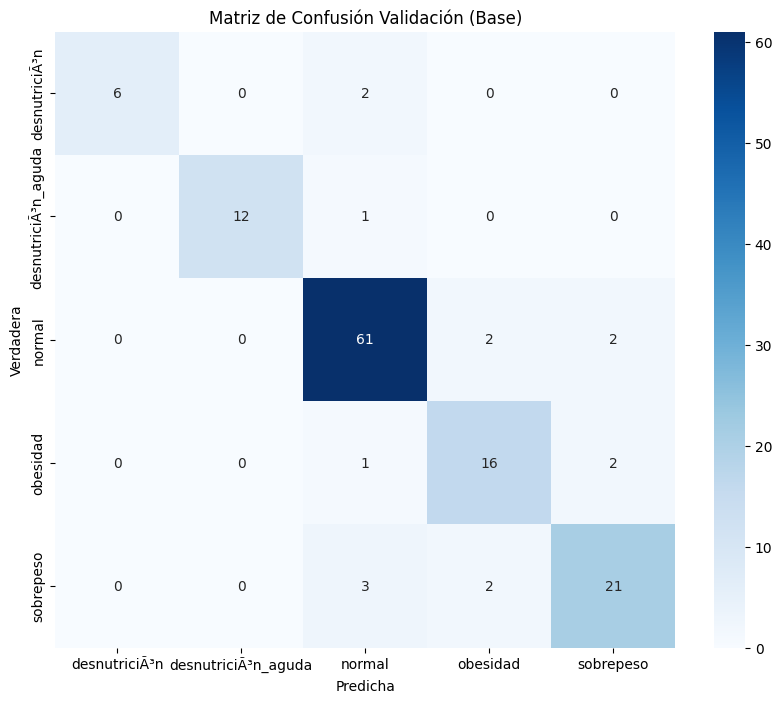


--- Fin de la Iteración 1: Corrección de Datos y Re-evaluación del Modelo Base ---


In [40]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Paso 2.Iter1.4: Re-entrenando y Re-evaluando el Modelo Base ---")

# Seleccionar los datos de entrenamiento (con o sin SMOTE)
X_train_for_fit = X_train_smote
y_train_for_fit = y_train_smote

# Preparar y_val_for_eval (ya debería ser un array NumPy 1D sin NaNs del Paso 2.Iter1.2)
y_val_for_eval = y_val_to_use 
if not isinstance(y_val_for_eval, np.ndarray) or \
   (hasattr(y_val_for_eval, 'ndim') and y_val_for_eval.ndim > 1) or \
   (hasattr(y_val_for_eval, 'dtype') and np.isnan(y_val_for_eval).any()):
    # Esto indica un problema en el Paso 2.Iter1.2 si y_val_to_use no está listo
    raise ValueError("y_val_to_use no está en el formato esperado (NumPy array, 1D, sin NaNs). Revisa Paso 2.Iter1.2.")

can_train_evaluate = True
if not isinstance(X_train_for_fit, (pd.DataFrame, np.ndarray)) or X_train_for_fit.shape[0] == 0 or \
   not isinstance(y_train_for_fit, np.ndarray) or y_train_for_fit.shape[0] == 0:
    print("ADVERTENCIA: Conjunto de entrenamiento (X o y) está vacío o no es del tipo esperado. No se puede entrenar.")
    can_train_evaluate = False

if not isinstance(X_val, (pd.DataFrame, np.ndarray)) or X_val.shape[0] == 0 or \
   not isinstance(y_val_for_eval, np.ndarray) or y_val_for_eval.shape[0] == 0:
    print("ADVERTENCIA: Conjunto de validación (X_val o y_val_for_eval) está vacío. La evaluación podría no ser posible o significativa.")
    if X_val.shape[0] == 0 : can_train_evaluate = False # Si X_val es vacío, no se puede predecir

if not can_train_evaluate:
    print("Saltando entrenamiento y evaluación debido a conjuntos de datos vacíos o inválidos.")
else:
    gb_model_iter1 = GradientBoostingClassifier(random_state=42)
    print("Re-entrenando el modelo Gradient Boosting...")
    try:
        gb_model_iter1.fit(X_train_for_fit, y_train_for_fit)
        print("Modelo (Iter1) re-entrenado exitosamente.")

        print("\nRe-evaluando el modelo (Iter1) en el conjunto de validación...")
        y_pred_val_iter1 = gb_model_iter1.predict(X_val)

        accuracy_val_iter1 = accuracy_score(y_val_for_eval, y_pred_val_iter1)
        print(f"Accuracy en validación (Iter1): {accuracy_val_iter1:.4f}")

        print("\nReporte de Clasificación en Validación (Iter1):")
        target_names_iter1 = label_encoder_y.classes_ if label_encoder_y and hasattr(label_encoder_y, 'classes_') else None
        report_iter1 = classification_report(
            y_val_for_eval, y_pred_val_iter1,
            target_names=target_names_iter1, zero_division=0
        )
        print(report_iter1)

        print("\nMatriz de Confusión en Validación (Iter1):")
        conf_matrix_iter1 = confusion_matrix(y_val_for_eval, y_pred_val_iter1)
        print(conf_matrix_iter1)
        
        if target_names_iter1 is not None:
            plt.figure(figsize=(10, 8))
            sns.heatmap(conf_matrix_iter1, annot=True, fmt='d', cmap='Blues',
                        xticklabels=target_names_iter1, yticklabels=target_names_iter1)
            plt.xlabel('Predicha')
            plt.ylabel('Verdadera')
            plt.title('Matriz de Confusión Validación (Base)')
            plt.show()
        else:
            print("\n(Nombres de las clases no disponibles para graficar la matriz de confusión con etiquetas detalladas)")

    except Exception as e:
        print(f"Error durante el re-entrenamiento o re-evaluación (Iter1): {e}")
        raise

print("\n--- Fin de la Iteración 1: Corrección de Datos y Re-evaluación del Modelo Base ---")

#### **Ajustar Hiperparámetros del GradientBoostingClassifier**

In [42]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from scipy.stats import randint, uniform # Para definir distribuciones de hiperparámetros
import joblib

print("\n--- Paso 2.5: Ajuste de Hiperparámetros con RandomizedSearchCV ---")

# Verificar que los datos de entrenamiento (potencialmente con SMOTE) estén listos
# X_train_for_fit y y_train_for_fit deberían ser los usados para gb_model_iter1
if 'X_train_for_fit' not in locals() or X_train_for_fit is None or \
   'y_train_for_fit' not in locals() or y_train_for_fit is None:
    raise ValueError("X_train_for_fit o y_train_for_fit no están definidos. Ejecuta los pasos anteriores de la Iteración 1.")

if (hasattr(X_train_for_fit, 'shape') and X_train_for_fit.shape[0] == 0) or \
   (hasattr(y_train_for_fit, 'shape') and y_train_for_fit.shape[0] == 0):
    raise ValueError("X_train_for_fit o y_train_for_fit están vacíos.")


# Definir el espacio de hiperparámetros para GradientBoostingClassifier
param_dist = {
    'n_estimators': randint(100, 500),       # Número de árboles
    'learning_rate': uniform(0.01, 0.2),     # Tasa de aprendizaje (distribución uniforme)
    'max_depth': randint(3, 7),              # Profundidad máxima de los árboles
    'subsample': uniform(0.7, 0.3),          # Fracción de muestras para ajustar cada árbol (0.7 a 1.0)
                                             # (uniform(loc, scale) => loc es el inicio, scale es el ancho del rango)
                                             # Entonces, para [0.7, 1.0], loc=0.7, scale=0.3
    'min_samples_split': randint(2, 11),     # Mínimo de muestras para dividir un nodo interno
    'min_samples_leaf': randint(1, 11)       # Mínimo de muestras en un nodo hoja
    # 'max_features': ['sqrt', 'log2', None] # Número de features a considerar en cada split (opcional)
}

# Crear el estimador base
gb_estimator = GradientBoostingClassifier(random_state=42)

# Configurar RandomizedSearchCV
# n_iter: Número de combinaciones de parámetros que se prueban.
# cv: Número de folds para la validación cruzada.
# scoring: Métrica a optimizar. 'f1_macro' es buena para desbalance, 'accuracy' es común.
#          Para multiclase, puedes usar 'f1_weighted' también.
# n_jobs=-1: Usar todos los procesadores disponibles.
random_search = RandomizedSearchCV(
    estimator=gb_estimator,
    param_distributions=param_dist,
    n_iter=50,  # Aumentar para una búsqueda más exhaustiva (ej. 50-100), pero tomará más tiempo
    cv=5,       # 3-fold o 5-fold cross-validation es común
    verbose=2,  # Muestra progreso
    random_state=42,
    n_jobs=-1,
    scoring='f1_weighted' # O 'accuracy', 'f1_macro'
)

print("Iniciando RandomizedSearchCV para GradientBoostingClassifier...")
try:
    # Ajustar RandomizedSearchCV a los datos de entrenamiento (X_train_for_fit, y_train_for_fit)
    random_search.fit(X_train_for_fit, y_train_for_fit)

    print("\nRandomizedSearchCV completado.")
    print(f"Mejor F1-score ponderado encontrado en validación cruzada: {random_search.best_score_:.4f}")
    print("Mejores hiperparámetros encontrados:")
    print(random_search.best_params_)

    # Obtener el mejor modelo
    best_gb_model = random_search.best_estimator_

    # Guardar el mejor modelo
    joblib.dump(best_gb_model, 'data/encoders/best_gradient_boosting_model.joblib')
    print("Mejor modelo Gradient Boosting guardado en 'best_gradient_boosting_model.joblib'")

except Exception as e:
    print(f"Error durante RandomizedSearchCV: {e}")
    # Si falla, podrías intentar con menos iteraciones (n_iter) o un espacio de parámetros más pequeño.
    # También verifica que X_train_for_fit y y_train_for_fit sean arrays/dataframes numéricos.
    raise

print("\n--- Fin del Paso 2.5: Ajuste de Hiperparámetros ---")


--- Paso 2.5: Ajuste de Hiperparámetros con RandomizedSearchCV ---
Iniciando RandomizedSearchCV para GradientBoostingClassifier...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

RandomizedSearchCV completado.
Mejor F1-score ponderado encontrado en validación cruzada: 0.9550
Mejores hiperparámetros encontrados:
{'learning_rate': np.float64(0.061755996320003385), 'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 489, 'subsample': np.float64(0.7623824988604566)}
Mejor modelo Gradient Boosting guardado en 'best_gradient_boosting_model.joblib'

--- Fin del Paso 2.5: Ajuste de Hiperparámetros ---


#### **Evaluar el Modelo Ajustado en el Conjunto de Validación**


--- Paso 2.6: Evaluando el Modelo Ajustado en el Conjunto de Validación ---
Usando 'best_estimator_' del objeto random_search.

Realizando predicciones con el modelo ajustado en el conjunto de validación...

Evaluación del modelo AJUSTADO en el conjunto de validación:
Accuracy en validación (ajustado): 0.8931

Reporte de Clasificación en Validación (ajustado):
                     precision    recall  f1-score   support

      desnutriciÃ³n       1.00      0.75      0.86         8
desnutriciÃ³n_aguda       1.00      0.92      0.96        13
             normal       0.89      0.97      0.93        65
           obesidad       0.84      0.84      0.84        19
          sobrepeso       0.87      0.77      0.82        26

           accuracy                           0.89       131
          macro avg       0.92      0.85      0.88       131
       weighted avg       0.90      0.89      0.89       131


Matriz de Confusión en Validación (ajustado):
[[ 6  0  2  0  0]
 [ 0 12  1  0  0]
 

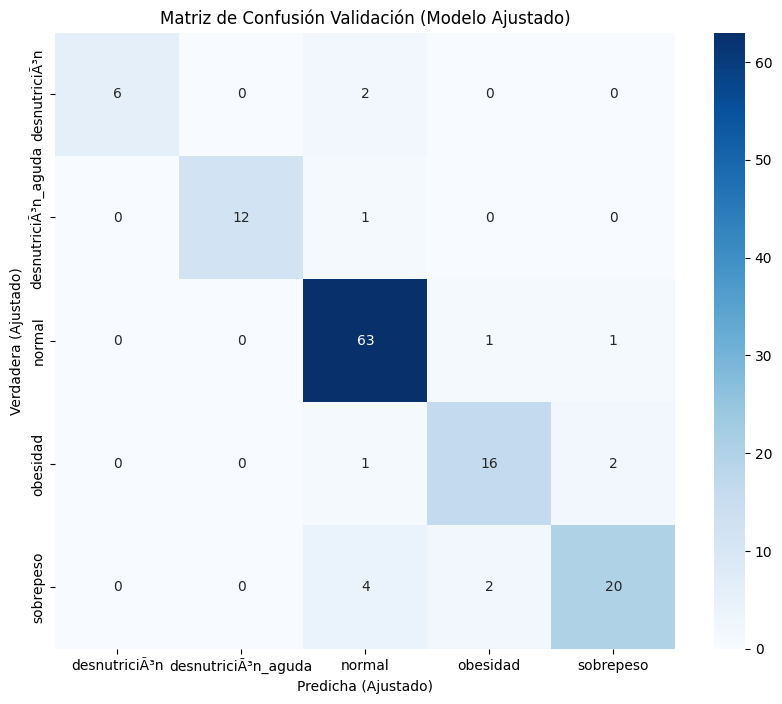


--- Fin del Paso 2.6: Evaluación del Modelo Ajustado en Validación ---


In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib 
import seaborn as sns
import matplotlib.pyplot as plt 

print("\n--- Paso 2.6: Evaluando el Modelo Ajustado en el Conjunto de Validación ---")

if 'best_gb_model_tuned' not in locals() and 'random_search' not in locals():
    try:
        best_gb_model_tuned = joblib.load('best_gradient_boosting_model.joblib')
        print("Mejor modelo cargado desde 'best_gradient_boosting_model.joblib'")
        
        # Opción: Recrear y entrenar el modelo con los mejores parámetros si no se puede cargar
        if 'random_search' in locals() and hasattr(random_search, 'best_params_'):
            print("Recreando el modelo con los best_params_ de random_search...")
            best_params_from_search = random_search.best_params_
        else:
            # Si no tienes random_search, usa los parámetros que anotaste:
            print("Usando los best_params_ anotados de la salida anterior...")
            best_params_from_search = {
                'learning_rate': 0.061755996320003385,
                'max_depth': 6,
                'min_samples_leaf': 4,
                'min_samples_split': 3,
                'n_estimators': 489,
                'subsample': 0.7623824988604566
            }
        
        best_gb_model_tuned = GradientBoostingClassifier(**best_params_from_search, random_state=42)
        # Asegúrate de que X_train_for_fit e y_train_for_fit estén disponibles para este re-entrenamiento
        if 'X_train_for_fit' in locals() and 'y_train_for_fit' in locals():
            print("Re-entrenando el modelo con los mejores parámetros...")
            best_gb_model_tuned.fit(X_train_for_fit, y_train_for_fit)
            print("Modelo re-entrenado con los mejores parámetros.")
        else:
            raise ValueError("X_train_for_fit o y_train_for_fit no están disponibles para re-entrenar el modelo.")
            
    except FileNotFoundError:
        print("ERROR: 'best_gradient_boosting_model.joblib' no encontrado. Asegúrate de haberlo guardado o de tener 'random_search' en memoria.")
        raise
elif 'random_search' in locals() and 'best_gb_model_tuned' not in locals(): 
    best_gb_model_tuned = random_search.best_estimator_
    print("Usando 'best_estimator_' del objeto random_search.")


# Asegurarse de que X_val e y_val_for_eval estén listos y no vacíos
if 'X_val' not in locals() or X_val.empty or \
   'y_val_for_eval' not in locals() or (hasattr(y_val_for_eval, 'shape') and y_val_for_eval.shape[0] == 0):
    raise ValueError("X_val o y_val_for_eval no están definidos o están vacíos. Revisa los pasos anteriores.")

print("\nRealizando predicciones con el modelo ajustado en el conjunto de validación...")
try:
    y_pred_val_tuned = best_gb_model_tuned.predict(X_val)
except Exception as e:
    print(f"Error durante la predicción en el conjunto de validación con el modelo ajustado: {e}")
    raise

print("\nEvaluación del modelo AJUSTADO en el conjunto de validación:")
accuracy_val_tuned = accuracy_score(y_val_for_eval, y_pred_val_tuned)
print(f"Accuracy en validación (ajustado): {accuracy_val_tuned:.4f}")

print("\nReporte de Clasificación en Validación (ajustado):")
# Asumimos que label_encoder_y está disponible desde el Paso 2.Iter1.2
target_names_final_val = label_encoder_y.classes_ if 'label_encoder_y' in locals() and label_encoder_y and hasattr(label_encoder_y, 'classes_') else None
report_tuned_val = classification_report(
    y_val_for_eval, 
    y_pred_val_tuned, 
    target_names=target_names_final_val,
    zero_division=0
)
print(report_tuned_val)

print("\nMatriz de Confusión en Validación (ajustado):")
conf_matrix_tuned_val = confusion_matrix(y_val_for_eval, y_pred_val_tuned)
print(conf_matrix_tuned_val)

# Visualización opcional
if target_names_final_val is not None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix_tuned_val, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names_final_val, yticklabels=target_names_final_val)
    plt.xlabel('Predicha (Ajustado)')
    plt.ylabel('Verdadera (Ajustado)')
    plt.title('Matriz de Confusión Validación (Modelo Ajustado)')
    plt.show()

print("\n--- Fin del Paso 2.6: Evaluación del Modelo Ajustado en Validación ---")

#### **Evaluación Final del Modelo Ajustado en el conjunto de Prueba (X_test)**


--- Paso 2.7: Evaluación Final del Modelo Ajustado en el Conjunto de Prueba ---

Realizando predicciones con el modelo ajustado en el conjunto de PRUEBA...

Evaluación del modelo AJUSTADO en el conjunto de PRUEBA:
Accuracy en PRUEBA (ajustado): 0.8779

Reporte de Clasificación en PRUEBA (ajustado):
                     precision    recall  f1-score   support

      desnutriciÃ³n       0.73      1.00      0.84         8
desnutriciÃ³n_aguda       1.00      0.92      0.96        13
             normal       0.90      0.92      0.91        65
           obesidad       0.83      0.79      0.81        19
          sobrepeso       0.87      0.77      0.82        26

           accuracy                           0.88       131
          macro avg       0.87      0.88      0.87       131
       weighted avg       0.88      0.88      0.88       131


Matriz de Confusión en PRUEBA (ajustado):
[[ 8  0  0  0  0]
 [ 0 12  1  0  0]
 [ 3  0 60  1  1]
 [ 0  0  2 15  2]
 [ 0  0  4  2 20]]


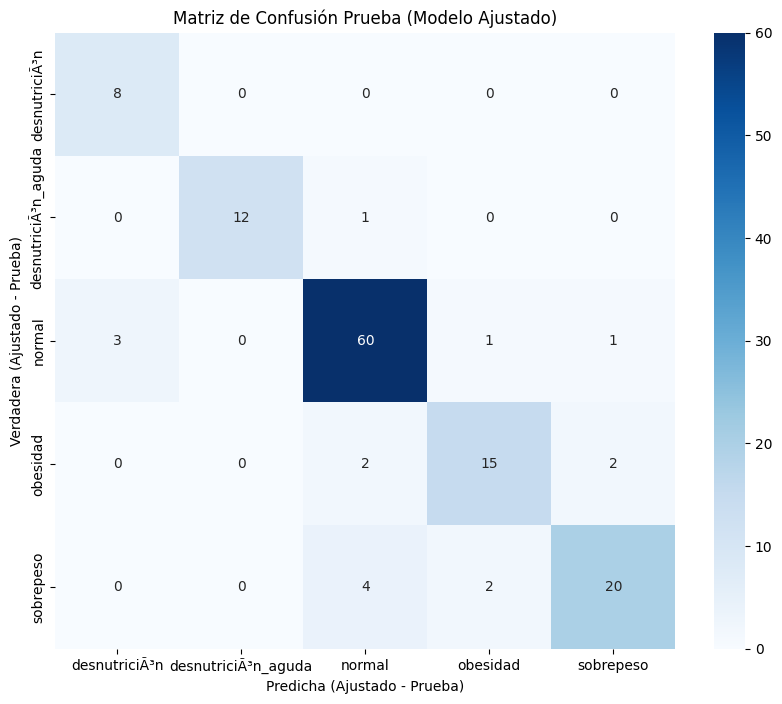


--- Fin del Paso 2.7: Evaluación Final del Modelo en Prueba ---


In [44]:
import joblib

print("\n--- Paso 2.7: Evaluación Final del Modelo Ajustado en el Conjunto de Prueba ---")

# Asegurarse de que X_test e y_test_to_use están listos y no vacíos
if 'X_test' not in locals() or X_test.empty or \
   'y_test_to_use' not in locals() or (hasattr(y_test_to_use, 'shape') and y_test_to_use.shape[0] == 0):
    raise ValueError("X_test o y_test_to_use no están definidos o están vacíos. Revisa los pasos anteriores.")

# Preparar y_test_for_eval (asegurando que es un array NumPy 1D sin NaNs)
y_test_for_eval = None
if isinstance(y_test_to_use, np.ndarray): # Si ya es ndarray (ej. de LabelEncoder o .values)
    y_test_for_eval = y_test_to_use
else: # Si no, intenta convertir (esto es un fallback, debería ser ndarray ya)
    try: y_test_for_eval = np.array(y_test_to_use)
    except: raise TypeError(f"y_test_to_use no es compatible. Tipo: {type(y_test_to_use)}")

if hasattr(y_test_for_eval, 'ndim') and y_test_for_eval.ndim > 1: y_test_for_eval = y_test_for_eval.ravel()
if np.isnan(y_test_for_eval).any(): raise ValueError("y_test_for_eval contiene NaNs después de la preparación.")


if X_test.shape[0] != y_test_for_eval.shape[0]:
    raise ValueError(f"Discrepancia FINAL en el número de muestras entre X_test ({X_test.shape[0]}) y y_test_for_eval ({y_test_for_eval.shape[0]}).")


if 'best_gb_model_tuned' not in locals():
    # Intenta cargar el modelo si no está en memoria
    try:
        best_gb_model_tuned = joblib.load('best_gradient_boosting_model.joblib')
        print("Mejor modelo ajustado cargado desde 'best_gradient_boosting_model.joblib'")
    except FileNotFoundError:
        print("ERROR: 'best_gradient_boosting_model.joblib' no encontrado y 'best_gb_model_tuned' no está en memoria.")
        raise
    except NameError as ne: # Captura el NameError si joblib no se importó y no se puede cargar
        print(f"ERROR: {ne}")
        raise


print("\nRealizando predicciones con el modelo ajustado en el conjunto de PRUEBA...")
try:
    y_pred_test_tuned = best_gb_model_tuned.predict(X_test)
except Exception as e:
    print(f"Error durante la predicción en el conjunto de prueba: {e}")
    raise

print("\nEvaluación del modelo AJUSTADO en el conjunto de PRUEBA:")
accuracy_test_tuned = accuracy_score(y_test_for_eval, y_pred_test_tuned)
print(f"Accuracy en PRUEBA (ajustado): {accuracy_test_tuned:.4f}")

print("\nReporte de Clasificación en PRUEBA (ajustado):")
# Asumimos que label_encoder_y está disponible desde el Paso 2.Iter1.2
target_names_final_test = label_encoder_y.classes_ if 'label_encoder_y' in locals() and label_encoder_y and hasattr(label_encoder_y, 'classes_') else None
report_tuned_test = classification_report(
    y_test_for_eval, 
    y_pred_test_tuned, 
    target_names=target_names_final_test,
    zero_division=0
)
print(report_tuned_test)

print("\nMatriz de Confusión en PRUEBA (ajustado):")
conf_matrix_tuned_test = confusion_matrix(y_test_for_eval, y_pred_test_tuned)
print(conf_matrix_tuned_test)

# Visualización opcional
if target_names_final_test is not None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix_tuned_test, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names_final_test, yticklabels=target_names_final_test)
    plt.xlabel('Predicha (Ajustado - Prueba)')
    plt.ylabel('Verdadera (Ajustado - Prueba)')
    plt.title('Matriz de Confusión Prueba (Modelo Ajustado)')
    plt.show()

print("\n--- Fin del Paso 2.7: Evaluación Final del Modelo en Prueba ---")

#### **Análisis de Importancia de las Características**


--- Paso 2.8: Análisis de Importancia de las Características ---

Importancia de las Características (Top 20):
    feature  importance
7         7    0.718419
11       11    0.049740
13       13    0.029899
4         4    0.021437
12       12    0.020323
10       10    0.017585
19       19    0.013354
22       22    0.011828
5         5    0.009985
34       34    0.008490
9         9    0.008360
37       37    0.007752
36       36    0.006865
23       23    0.006752
3         3    0.006431
2         2    0.005632
1         1    0.005497
35       35    0.005234
6         6    0.005232
16       16    0.005095


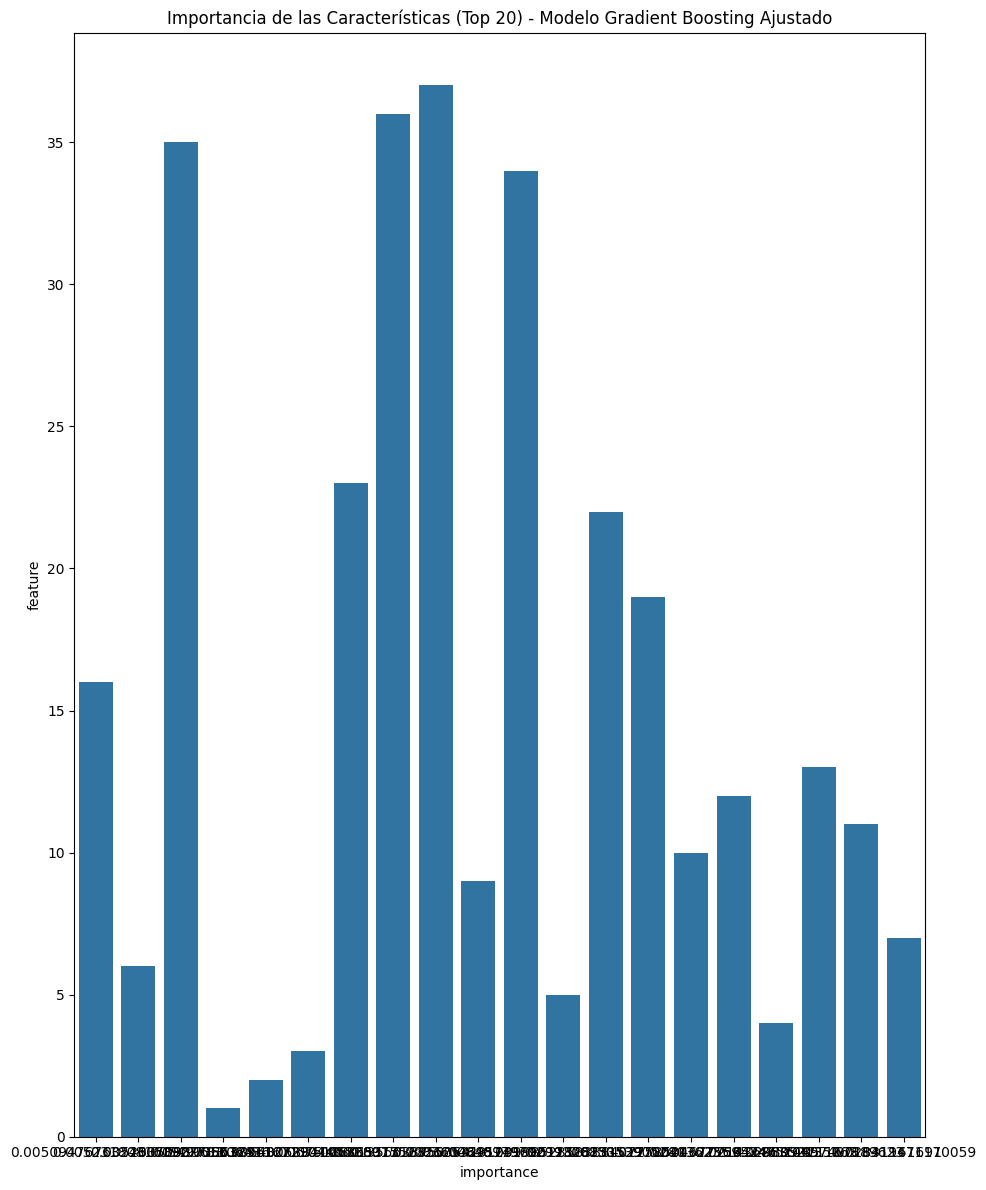


--- Fin del Paso 2.8: Análisis de Importancia de Características ---


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Para mejores gráficos
import joblib

print("\n--- Paso 2.8: Análisis de Importancia de las Características ---")

if 'best_gb_model_tuned' not in locals():
    try:
        best_gb_model_tuned = joblib.load('data/encoders/best_gradient_boosting_model.joblib')
        print("Mejor modelo ajustado cargado.")
    except FileNotFoundError:
        print("ERROR: Archivo 'best_gradient_boosting_model.joblib' no encontrado.")
        raise SystemExit("Modelo no disponible para análisis de importancia.")
    raise NameError("'best_gb_model_tuned' no está definido. Asegúrate de que el modelo ajustado esté disponible.")


if hasattr(best_gb_model_tuned, 'feature_importances_'):
    feature_importances = best_gb_model_tuned.feature_importances_
    
    # Extraer los nombres de las columnas de X_train_for_fit
    if isinstance(X_train_for_fit, pd.DataFrame):
        feature_names = X_train_for_fit.columns
    elif 'processed_feature_names' in locals() and len(processed_feature_names) == X_train_for_fit.shape[1]:
        feature_names = processed_feature_names
    elif 'X_train' in locals() and isinstance(X_train, pd.DataFrame) and X_train.shape[1] == len(feature_importances):
        feature_names = X_train.columns 
    else:
        print("ADVERTENCIA: No se pudieron obtener los nombres de las características de forma fiable.")
        print("Creando nombres genéricos. Revisa si el preprocesador está disponible para obtener los nombres correctos.")
        feature_names = [f"feature_{i}" for i in range(len(feature_importances))]
    
    importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
    importance_df = importance_df.sort_values(by='importance', ascending=False)

    print("\nImportancia de las Características (Top 20):")
    print(importance_df.head(20))

    # Graficar la importancia de las características
    plt.figure(figsize=(10, 12)) 
    sns.barplot(x='importance', y='feature', data=importance_df.head(20))
    plt.title('Importancia de las Características (Top 20) - Modelo Gradient Boosting Ajustado')
    plt.tight_layout() # Ajustar el layout para que no se corten las etiquetas
    plt.show()
else:
    print("El modelo ajustado no tiene el atributo 'feature_importances_'.")

print("\n--- Fin del Paso 2.8: Análisis de Importancia de Características ---")

#### **Guardar el Modelo Final y Componentes Necesarios**

In [50]:
import joblib

print("\n--- Paso 2.9: Guardando el Modelo Final y Componentes ---")

joblib.dump(best_gb_model_tuned, 'best_gradient_boosting_model_final.joblib')
print("Mejor modelo Gradient Boosting (final) guardado en 'best_gradient_boosting_model_final.joblib'")

# Guardar el LabelEncoder para 'y' (si se usó)
if 'label_encoder_y' in locals() and label_encoder_y is not None:
    try:
        joblib.dump(label_encoder_y, 'label_encoder_y_final.joblib')
        print("LabelEncoder para 'y' guardado en 'label_encoder_y_final.joblib'")
    except Exception as e:
        print(f"Error al guardar label_encoder_y: {e}")

# Guardar el ColumnTransformer preprocessor
if 'preprocessor' in locals() and preprocessor is not None:
    try:
        joblib.dump(preprocessor, 'preprocessor_final.joblib')
        print("ColumnTransformer preprocessor guardado en 'preprocessor_final.joblib'")
    except Exception as e:
        print(f"Error al guardar preprocessor: {e}")
else:
    print("ADVERTENCIA: El objeto 'preprocessor' (ColumnTransformer) no está disponible para ser guardado.")
    print("Necesitarás este preprocesador para procesar nuevos datos antes de la predicción.")

print("\n--- Fin del Paso 2.9: Guardado de Componentes ---")


--- Paso 2.9: Guardando el Modelo Final y Componentes ---
Mejor modelo Gradient Boosting (final) guardado en 'best_gradient_boosting_model_final.joblib'
LabelEncoder para 'y' guardado en 'label_encoder_y_final.joblib'
ColumnTransformer preprocessor guardado en 'preprocessor_final.joblib'

--- Fin del Paso 2.9: Guardado de Componentes ---
